# Bias Detection — Classical Baseline & Ablation: BoW vs BoW + POS/Lexicon/Style

**Data:** `anno_lexical_{train,dev,test}_clean.csv` (outputs of the prior audit notebook)

**Goal:** train a classical bias classifier (TF-IDF bag-of-words) and test whether adding the
POS-density / loaded-language-lexicon / stylistic features from the EDA notebook improves it —
directly testing the topic-confound concern flagged in that notebook (raw vocabulary may partly
be learning *topic*, not *style*).

**Protocol:**
- Model/hyperparameter selection happens on **dev** only.
- **test** is touched exactly once, at the end, for each of the two final chosen models.
- Two feature sets compared head-to-head under identical model/hyperparameter search:
  1. `bow` — TF-IDF word n-grams only.
  2. `bow_plus` — same TF-IDF, concatenated with POS/lexicon/style/sentiment features.
- Two model families tried per feature set: Logistic Regression, Linear SVM.


In [1]:
%pip install --quiet pandas numpy scikit-learn nltk matplotlib scipy

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

Note: you may need to restart the kernel to use updated packages.


In [1]:
import os
os.environ.setdefault("NLTK_DISABLE_IMPORT_SECURITY", "1")  # see prior troubleshooting notes

import re
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter

import nltk
from nltk import pos_tag, word_tokenize
from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer

for pkg in ["averaged_perceptron_tagger_eng", "punkt_tab", "stopwords", "vader_lexicon"]:
    nltk.download(pkg, quiet=True)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from scipy.sparse import hstack, csr_matrix

import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option('display.max_colwidth', 100)

## 0. Load Data


In [3]:
DATA_DIR = Path("./data/outputs")
OUTPUT_DIR = Path("./data/outputs")

train = pd.read_csv(DATA_DIR / "anno_lexical_train_clean.csv")
dev = pd.read_csv(DATA_DIR / "anno_lexical_dev_clean.csv")
test = pd.read_csv(DATA_DIR / "anno_lexical_test_clean.csv")

for name, df in [("train", train), ("dev", dev), ("test", test)]:
    print(f"{name}: {df.shape}, label balance = {df['label'].mean():.3f}")

train.head(3)

train: (33831, 6), label balance = 0.497
dev: (7249, 6), label balance = 0.506
test: (7250, 6), label balance = 0.507


,sentence_id,text,source_name,label,label_name,split
0,31bef2d8-f7e5-42ce-a278-ae201dd3e1fe,"General Admission: $25, $20 for seniors and military; $10 for students at sacraprofana.org.",san-diego-uniontribune,0,non-biased,train
1,412c7cde-e3b4-46c5-b91d-c0b7b1d813e1,Proceeds benefit children and adults with disabilities at The Arc of San Diego.,san-diego-uniontribune,0,non-biased,train
2,6e2d7083-52da-4072-989b-ca42e5d69679,One day before he is set to surrender to authorities for the fourth time in five months to face ...,alternet,1,biased,train


## 1. Engineered Features: POS / Lexicon / Style / Sentiment

Same feature definitions as the EDA notebook, applied consistently across all three splits.
Fit any *learned* transforms (only `StandardScaler` here) on **train only**, then transform
dev/test — the same rule as the TF-IDF vectorizer below.


In [4]:
STOPWORDS = set(stopwords.words("english"))

LEXICON = {
    "intensifiers": ["very", "extremely", "clearly", "obviously", "absolutely", "totally",
                      "completely", "utterly", "highly", "incredibly", "remarkably"],
    "hedges": ["may", "might", "could", "possibly", "perhaps", "seem", "seems", "appear",
               "appears", "suggest", "suggests", "reportedly", "allegedly"],
    "one_sided_assertive": ["radical", "extremist", "disgraceful", "outrageous", "shocking",
                              "corrupt", "failed", "disastrous", "brilliant", "heroic",
                              "devastating", "slammed", "blasted", "destroyed", "crushed"],
}

POS_GROUPS = {
    "ADJ": {"JJ", "JJR", "JJS"},
    "ADV": {"RB", "RBR", "RBS"},
    "NOUN": {"NN", "NNS", "NNP", "NNPS"},
    "VERB": {"VB", "VBD", "VBG", "VBN", "VBP", "VBZ"},
}

sia = SentimentIntensityAnalyzer()

def tokenize_words(text):
    return [t.lower() for t in re.findall(r"[A-Za-z']+", text) if len(t) > 1]

def engineer_features(text):
    words_raw = str(text).split()
    tags = [t for _, t in pos_tag(word_tokenize(str(text)))]
    n_tags = len(tags) or 1
    toks = tokenize_words(text)

    feats = {}
    # POS density
    for group, tagset in POS_GROUPS.items():
        feats[f"pos_{group.lower()}"] = sum(1 for t in tags if t in tagset) / n_tags
    # Lexicon hit indicators (0/1: does the sentence contain >=1 word from the category)
    for category, wordlist in LEXICON.items():
        wset = set(wordlist)
        feats[f"lex_{category}"] = 1.0 if any(t in wset for t in toks) else 0.0
    # Style / surface features
    feats["n_words"] = len(words_raw)
    feats["n_exclaim"] = str(text).count("!")
    feats["n_question"] = str(text).count("?")
    feats["n_quotes"] = str(text).count('"') + str(text).count("'")
    feats["pct_allcaps_words"] = (
        sum(1 for w in words_raw if w.isupper() and len(w) > 1) / len(words_raw) if words_raw else 0.0
    )
    # Sentiment
    feats["vader_compound"] = sia.polarity_scores(str(text))["compound"]
    return feats

FEATURE_NAMES = list(engineer_features("Sample sentence for schema.").keys())
print(f"Engineered feature count: {len(FEATURE_NAMES)}")
print(FEATURE_NAMES)

Engineered feature count: 13
['pos_adj', 'pos_adv', 'pos_noun', 'pos_verb', 'lex_intensifiers', 'lex_hedges', 'lex_one_sided_assertive', 'n_words', 'n_exclaim', 'n_question', 'n_quotes', 'pct_allcaps_words', 'vader_compound']


In [5]:
def build_feature_matrix(df):
    rows = df["text"].apply(engineer_features).apply(pd.Series)
    return rows[FEATURE_NAMES]

print("Engineering features for train/dev/test (POS tagging ~30-60s for train)...")
X_extra_train_raw = build_feature_matrix(train)
X_extra_dev_raw = build_feature_matrix(dev)
X_extra_test_raw = build_feature_matrix(test)
print("Done.")
X_extra_train_raw.describe().T[["mean", "std", "min", "max"]]

Engineering features for train/dev/test (POS tagging ~30-60s for train)...
Done.


,mean,std,min,max
pos_adj,0.079554,0.055857,0.0000,0.416667
pos_adv,0.042490,0.045503,0.0000,0.428571
pos_noun,0.286161,0.099493,0.0000,0.933333
pos_verb,0.147457,0.061933,0.0000,0.437500
lex_intensifiers,0.028051,0.165122,0.0000,1.000000
lex_hedges,0.080725,0.272416,0.0000,1.000000
lex_one_sided_assertive,0.015666,0.124182,0.0000,1.000000
n_words,23.647335,10.680429,3.0000,309.000000
n_exclaim,0.004936,0.071753,0.0000,3.000000
n_question,0.034968,0.251489,0.0000,32.000000


In [6]:
# Scale numeric features -- fit on train only
scaler = StandardScaler()
X_extra_train = scaler.fit_transform(X_extra_train_raw)
X_extra_dev = scaler.transform(X_extra_dev_raw)
X_extra_test = scaler.transform(X_extra_test_raw)

X_extra_train = csr_matrix(X_extra_train)
X_extra_dev = csr_matrix(X_extra_dev)
X_extra_test = csr_matrix(X_extra_test)

## 2. TF-IDF Bag-of-Words

Fit strictly on train. Unigrams + bigrams, English stopwords removed, standard TF-IDF weighting.


In [7]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.9,
    stop_words="english",
    sublinear_tf=True,
)

X_bow_train = tfidf.fit_transform(train["text"])
X_bow_dev = tfidf.transform(dev["text"])
X_bow_test = tfidf.transform(test["text"])

print(f"Vocabulary size: {len(tfidf.vocabulary_)}")
print(f"Train matrix shape: {X_bow_train.shape}")

Vocabulary size: 25349
Train matrix shape: (33831, 25349)


## 3. Assemble the Two Feature Sets


In [8]:
y_train, y_dev, y_test = train["label"].values, dev["label"].values, test["label"].values

feature_sets = {
    "bow": {
        "train": X_bow_train, "dev": X_bow_dev, "test": X_bow_test,
    },
    "bow_plus": {
        "train": hstack([X_bow_train, X_extra_train]).tocsr(),
        "dev": hstack([X_bow_dev, X_extra_dev]).tocsr(),
        "test": hstack([X_bow_test, X_extra_test]).tocsr(),
    },
}

for name, fs in feature_sets.items():
    print(f"{name}: train shape = {fs['train'].shape}")

bow: train shape = (33831, 25349)
bow_plus: train shape = (33831, 25362)


## 4. Model Selection on Dev

Try Logistic Regression and Linear SVM, each over a small `C` grid, for **each** feature set.
Selection metric: macro-F1 on dev (appropriate given the near-balanced classes, and consistent
with the class-imbalance-aware default recommended in the audit notebook). The dev set drives
every choice here — test stays untouched until Section 6.


In [9]:
MODEL_GRID = {
    "logreg": lambda C: LogisticRegression(C=C, max_iter=2000, random_state=RANDOM_STATE),
    "linear_svm": lambda C: LinearSVC(C=C, random_state=RANDOM_STATE),
}
C_VALUES = [0.01, 0.1, 1, 10]

results = []
fitted_models = {}

for fs_name, fs in feature_sets.items():
    for model_name, model_fn in MODEL_GRID.items():
        for C in C_VALUES:
            clf = model_fn(C)
            clf.fit(fs["train"], y_train)
            pred_dev = clf.predict(fs["dev"])
            acc = accuracy_score(y_dev, pred_dev)
            f1_macro = f1_score(y_dev, pred_dev, average="macro")
            results.append({
                "feature_set": fs_name, "model": model_name, "C": C,
                "dev_accuracy": acc, "dev_macro_f1": f1_macro,
            })
            fitted_models[(fs_name, model_name, C)] = clf

results_df = pd.DataFrame(results).sort_values(["feature_set", "dev_macro_f1"], ascending=[True, False])
results_df

,feature_set,model,C,dev_accuracy,dev_macro_f1
2,bow,logreg,1.00,0.711271,0.711270
5,bow,linear_svm,0.10,0.711133,0.711133
3,bow,logreg,10.00,0.699959,0.699957
6,bow,linear_svm,1.00,0.696096,0.696096
1,bow,logreg,0.10,0.688785,0.688623
4,bow,linear_svm,0.01,0.687957,0.687736
0,bow,logreg,0.01,0.673748,0.670835
7,bow,linear_svm,10.00,0.667954,0.667943
13,bow_plus,linear_svm,0.10,0.714443,0.714442
10,bow_plus,logreg,1.00,0.713202,0.713202


In [10]:
# Best model per feature set, by dev macro-F1
best_per_feature_set = results_df.loc[results_df.groupby("feature_set")["dev_macro_f1"].idxmax()]
best_per_feature_set

,feature_set,model,C,dev_accuracy,dev_macro_f1
2,bow,logreg,1.0,0.711271,0.711270
13,bow_plus,linear_svm,0.1,0.714443,0.714442


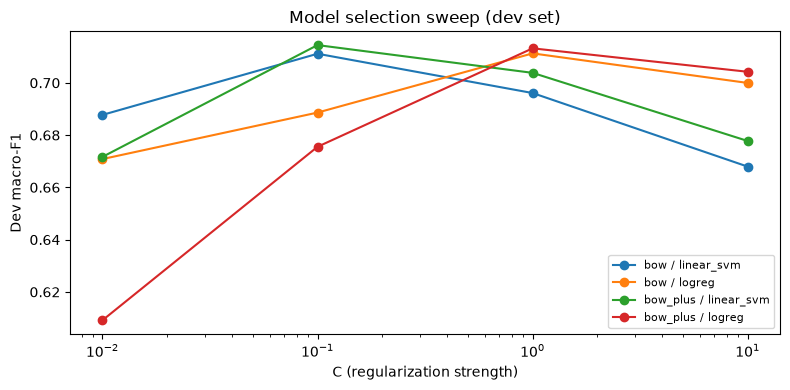

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
for (fs_name, model_name), grp in results_df.groupby(["feature_set", "model"]):
    grp_sorted = grp.sort_values("C")
    ax.plot(grp_sorted["C"], grp_sorted["dev_macro_f1"], marker="o", label=f"{fs_name} / {model_name}")
ax.set_xscale("log")
ax.set_xlabel("C (regularization strength)")
ax.set_ylabel("Dev macro-F1")
ax.set_title("Model selection sweep (dev set)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 5. Final Models

Lock in the best (feature_set, model, C) combination per feature set from Section 4.


In [12]:
final_keys = {}
for fs_name in feature_sets:
    row = best_per_feature_set[best_per_feature_set["feature_set"] == fs_name].iloc[0]
    final_keys[fs_name] = (fs_name, row["model"], row["C"])
    print(f"{fs_name}: model={row['model']}, C={row['C']}, dev_macro_f1={row['dev_macro_f1']:.4f}")

final_models = {fs_name: fitted_models[key] for fs_name, key in final_keys.items()}

bow: model=logreg, C=1.0, dev_macro_f1=0.7113
bow_plus: model=linear_svm, C=0.1, dev_macro_f1=0.7144


## 6. Test Set Evaluation (touched once, here only)


In [13]:
test_results = []
predictions = {}

for fs_name, clf in final_models.items():
    pred_test = clf.predict(feature_sets[fs_name]["test"])
    predictions[fs_name] = pred_test
    acc = accuracy_score(y_test, pred_test)
    f1_macro = f1_score(y_test, pred_test, average="macro")
    test_results.append({"feature_set": fs_name, "test_accuracy": acc, "test_macro_f1": f1_macro})
    print(f"\n=== {fs_name} ({final_keys[fs_name][1]}, C={final_keys[fs_name][2]}) ===")
    print(classification_report(y_test, pred_test, target_names=["non-biased", "biased"]))

test_results_df = pd.DataFrame(test_results)
test_results_df


=== bow (logreg, C=1.0) ===
              precision    recall  f1-score   support

  non-biased       0.70      0.72      0.71      3572
      biased       0.72      0.70      0.71      3678

    accuracy                           0.71      7250
   macro avg       0.71      0.71      0.71      7250
weighted avg       0.71      0.71      0.71      7250


=== bow_plus (linear_svm, C=0.1) ===
              precision    recall  f1-score   support

  non-biased       0.70      0.73      0.71      3572
      biased       0.73      0.70      0.71      3678

    accuracy                           0.71      7250
   macro avg       0.71      0.71      0.71      7250
weighted avg       0.71      0.71      0.71      7250



,feature_set,test_accuracy,test_macro_f1
0,bow,0.708138,0.708136
1,bow_plus,0.714207,0.714206


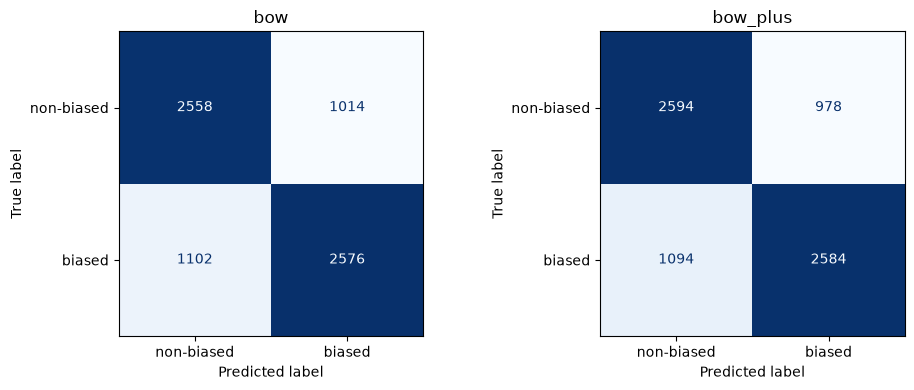

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (fs_name, pred_test) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, pred_test)
    disp = ConfusionMatrixDisplay(cm, display_labels=["non-biased", "biased"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(fs_name)
plt.tight_layout()
plt.show()

## 7. Ablation Comparison


In [15]:
ablation = test_results_df.set_index("feature_set")
delta_acc = ablation.loc["bow_plus", "test_accuracy"] - ablation.loc["bow", "test_accuracy"]
delta_f1 = ablation.loc["bow_plus", "test_macro_f1"] - ablation.loc["bow", "test_macro_f1"]

print(f"bow           -> accuracy: {ablation.loc['bow', 'test_accuracy']:.4f}, macro-F1: {ablation.loc['bow', 'test_macro_f1']:.4f}")
print(f"bow_plus      -> accuracy: {ablation.loc['bow_plus', 'test_accuracy']:.4f}, macro-F1: {ablation.loc['bow_plus', 'test_macro_f1']:.4f}")
print(f"\nDelta from adding POS/lexicon/style/sentiment features:")
print(f"  accuracy: {delta_acc:+.4f}")
print(f"  macro-F1: {delta_f1:+.4f}")

bow           -> accuracy: 0.7081, macro-F1: 0.7081
bow_plus      -> accuracy: 0.7142, macro-F1: 0.7142

Delta from adding POS/lexicon/style/sentiment features:
  accuracy: +0.0061
  macro-F1: +0.0061


## 8. Interpretability: Top Weighted Features

Inspect what each model actually leaned on. For `bow`, top TF-IDF terms by coefficient magnitude.
For `bow_plus`, isolate the coefficients on the engineered (non-TF-IDF) block specifically —
this is the direct answer to "did the model actually use the POS/lexicon/style signal, or did it
just ignore it in favor of vocabulary."


In [16]:
def get_coefficients(clf):
    # Both LogisticRegression and LinearSVC expose .coef_ for binary classification
    return clf.coef_.ravel()

bow_clf = final_models["bow"]
bow_vocab = np.array(tfidf.get_feature_names_out())
bow_coefs = get_coefficients(bow_clf)

top_pos_idx = np.argsort(bow_coefs)[-20:][::-1]
top_neg_idx = np.argsort(bow_coefs)[:20]

print("Top terms pushing toward BIASED:")
for i in top_pos_idx:
    print(f"  {bow_vocab[i]:20s} {bow_coefs[i]:.3f}")

print("\nTop terms pushing toward NON-BIASED:")
for i in top_neg_idx:
    print(f"  {bow_vocab[i]:20s} {bow_coefs[i]:.3f}")

Top terms pushing toward BIASED:
  trump                4.128
  biden                3.521
  hamas                3.285
  illegal              3.236
  god                  3.080
  conservatives        2.909
  lie                  2.704
  leftist              2.638
  white                2.595
  political            2.579
  evil                 2.552
  anti                 2.486
  radical              2.404
  hate                 2.387
  woke                 2.379
  mention              2.323
  democracy            2.320
  democrats            2.309
  jews                 2.294
  agenda               2.269

Top terms pushing toward NON-BIASED:
  said                 -4.179
  according            -3.640
  noted                -2.439
  nov                  -2.411
  changes              -2.051
  2019                 -2.032
  asked                -2.024
  wednesday            -1.983
  announced            -1.976
  including            -1.975
  include              -1.909
  reported         

In [17]:
bow_plus_clf = final_models["bow_plus"]
bow_plus_coefs = get_coefficients(bow_plus_clf)

# The engineered features were appended after the TF-IDF block, in FEATURE_NAMES order
n_bow_features = X_bow_train.shape[1]
extra_coefs = bow_plus_coefs[n_bow_features:]

extra_coef_df = pd.DataFrame({
    "feature": FEATURE_NAMES,
    "coefficient": extra_coefs,
}).sort_values("coefficient", ascending=False)

extra_coef_df

,feature,coefficient
7,n_words,0.083553
0,pos_adj,0.059200
1,pos_adv,0.051492
6,lex_one_sided_assertive,0.042695
8,n_exclaim,0.033565
3,pos_verb,0.031009
4,lex_intensifiers,0.020668
9,n_question,0.016812
5,lex_hedges,0.006984
11,pct_allcaps_words,0.003570


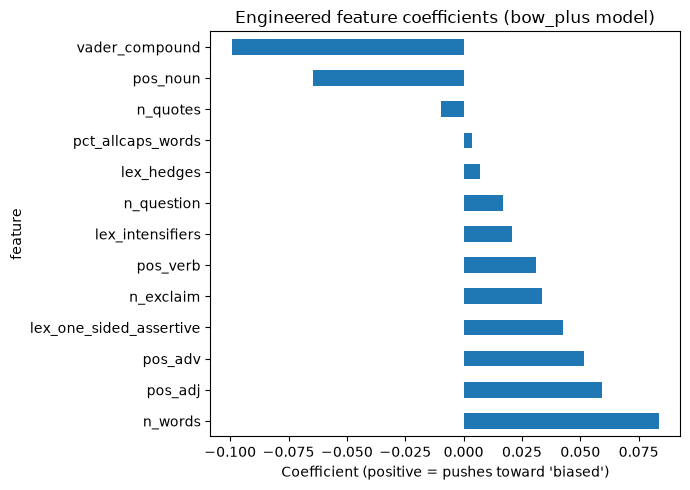

In [18]:
fig, ax = plt.subplots(figsize=(7, 5))
extra_coef_df.set_index("feature")["coefficient"].plot(kind="barh", ax=ax)
ax.set_title("Engineered feature coefficients (bow_plus model)")
ax.set_xlabel("Coefficient (positive = pushes toward 'biased')")
plt.tight_layout()
plt.show()

## 9. Summary

**What this notebook establishes:**

- A TF-IDF + linear model baseline is reported in Section 6 (`bow`), with the model/C chosen
  purely on dev performance, evaluated on test exactly once.
- The ablation (Section 7) gives a direct answer to whether POS/lexicon/style/sentiment features
  add anything beyond bag-of-words — read the printed deltas before drawing conclusions elsewhere
  in the write-up, since the sign and size of that gap is the main empirical finding here.
- Section 8's engineered-feature coefficient table is the important follow-up to the topic-confound
  concern raised in the EDA notebook: if `pos_adj`, `pos_adv`, or the `lex_*` features carry
  non-trivial weight in the same direction the EDA analysis suggested, that's evidence the model
  is using genuine stylistic signal rather than relying purely on topical vocabulary. If their
  coefficients are near-zero, it suggests the TF-IDF vocabulary already captured (or dominated)
  that signal, or that these particular engineered features aren't adding independent value in
  their current form.

**Known limitation carried over from the audit/EDA notebooks:** this baseline does not control
for outlet identity. A natural follow-up is a source-holdout evaluation (train on a subset of
outlets, test on entirely unseen outlets) to check whether performance holds up outside the
outlets seen in `anno_lexical`'s own train split — the EDA notebook's outlet-concentration check
was reassuring at the vocabulary level, but a held-out-source test is the more direct test of
generalization for this dataset.

**Next step options:** (a) source-holdout generalization test, (b) LLM zero-shot bias labeling
as a second baseline for the AI-assisted comparison arm of the project, or (c) moving to Task A
(topic classification) at the same modeling stage, now that Task B has a working baseline.
